# SECOM Preprocessing Pipeline

**Project:** AIoT Predictive Maintenance for Semiconductor Test Equipment  
**Module:** LD7182 — AI for IoT  
**Author:** Rekhanth Reddy Obireddy  
**Date:** 30 April 2026

## Goal
Apply the preprocessing strategy defined in `01_secom_exploration.ipynb`
to produce a clean, modelling-ready dataset.

## Pipeline Steps
1. Load SECOM dataset
2. Drop features with ≥50% missing values
3. Drop constant/near-zero variance features
4. Impute remaining missing values (median)
5. Standardise features (z-score)
6. Save preprocessed data

## Reference
Findings from exploration notebook:
- 1567 samples × 590 features
- Class imbalance: 6.6% fail (104 samples)
- 28 features with ≥50% missing → drop
- 276 features with zero/near-zero variance → drop
- Expected post-preprocessing: ~280-290 features

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import joblib
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Download SECOM dataset from UCI
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data

# Load
X = pd.read_csv('secom.data', sep=' ', header=None, na_values='NaN')
y_raw = pd.read_csv('secom_labels.data', sep=' ', header=None,
                    names=['label', 'timestamp'])
y = y_raw['label']

print(f"Loaded SECOM: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution: {dict(y.value_counts())}")

Loaded SECOM: 1567 samples, 590 features
Class distribution: {-1: np.int64(1463), 1: np.int64(104)}


## Step 1: Drop Features with High Missing Values

In [4]:
# Calculate missing percentage per feature
missing_pct = X.isnull().sum() / len(X) * 100

# Identify features to drop
high_missing_features = missing_pct[missing_pct >= 50].index.tolist()

print(f"Features with ≥50% missing values: {len(high_missing_features)}")
print(f"\nDropping these features...")

# Drop them
X_step1 = X.drop(columns=high_missing_features)

print(f"Before: {X.shape[1]} features")
print(f"After:  {X_step1.shape[1]} features")
print(f"Dropped: {X.shape[1] - X_step1.shape[1]} features")

Features with ≥50% missing values: 28

Dropping these features...
Before: 590 features
After:  562 features
Dropped: 28 features


## Step 2: Drop Constant and Near-Zero Variance Features

Features with zero or near-zero variance carry no information.
Per exploration: 116 zero-variance + 160 near-zero variance features.

In [5]:
# Calculating variance for each remaining feature
# Use NaN-safe computation
variance = X_step1.var()

# Identify constant and near-zero variance features (threshold: 0.01)
zero_var_features = variance[variance == 0].index.tolist()
near_zero_var_features = variance[(variance > 0) & (variance < 0.01)].index.tolist()
all_low_var_features = zero_var_features + near_zero_var_features

print(f"Zero variance features:      {len(zero_var_features)}")
print(f"Near-zero variance features: {len(near_zero_var_features)}")
print(f"Total to drop:               {len(all_low_var_features)}")

# Drop them
X_step2 = X_step1.drop(columns=all_low_var_features)

print(f"\nBefore: {X_step1.shape[1]} features")
print(f"After:  {X_step2.shape[1]} features")
print(f"Cumulative dropped: {X.shape[1] - X_step2.shape[1]} features ({(X.shape[1] - X_step2.shape[1])/X.shape[1]*100:.1f}%)")

Zero variance features:      116
Near-zero variance features: 149
Total to drop:               265

Before: 562 features
After:  297 features
Cumulative dropped: 293 features (49.7%)


## Verify the data still has missing values to impute

In [6]:
# Verify there are still missing values to handle
remaining_missing = X_step2.isnull().sum().sum()
total_cells = X_step2.shape[0] * X_step2.shape[1]
remaining_missing_pct = remaining_missing / total_cells * 100

print(f"Remaining missing values to impute: {remaining_missing:,}")
print(f"As percentage: {remaining_missing_pct:.2f}%")
print(f"Features still containing missing: {(X_step2.isnull().any()).sum()}")

Remaining missing values to impute: 7,052
As percentage: 1.52%
Features still containing missing: 268


## Step 3: Median Imputation

Apply median imputation to the remaining ~7,000 missing values.
Median is preferred over mean because SECOM features contain outliers
(real sensor anomalies) that would distort mean values.

In [7]:
# Apply median imputation
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_step2)

# Convert back to DataFrame to keep column names
X_imputed = pd.DataFrame(X_imputed, columns=X_step2.columns, index=X_step2.index)

# Verify no missing values remain
remaining_missing = X_imputed.isnull().sum().sum()

print(f"Remaining missing values after imputation: {remaining_missing}")
print(f"Shape after imputation: {X_imputed.shape}")

if remaining_missing == 0:
    print("\n✅ All missing values successfully imputed")
else:
    print("\n⚠️ Warning: some missing values remain")

Remaining missing values after imputation: 0
Shape after imputation: (1567, 297)

✅ All missing values successfully imputed


## Step 4: Standardisation (Z-score)

Apply z-score standardisation so all features have mean=0 and std=1.
Critical because SECOM features span 6+ orders of magnitude.

Note: In a production pipeline, scaling would be fit on training data
only, then applied to test data, to prevent data leakage. Here we
fit on the full dataset for exploration; the modelling notebook
(`03_baseline_models.ipynb`) will redo this properly with train/test split.

In [8]:
# Apply z-score standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X_imputed.columns, index=X_imputed.index)

# Verify the scaling worked
print(f"Shape: {X_scaled.shape}")
print(f"\nSample feature stats (first 5 features):")
print(X_scaled.iloc[:, :5].describe().round(3).T[['mean', 'std', 'min', 'max']])

Shape: (1567, 297)

Sample feature stats (first 5 features):
   mean  std    min     max
0   0.0  1.0 -3.692   4.655
1  -0.0  1.0 -4.203   4.371
2  -0.0  1.0 -4.763   3.906
3  -0.0  1.0 -3.174   5.276
4   0.0  1.0 -0.062  19.798


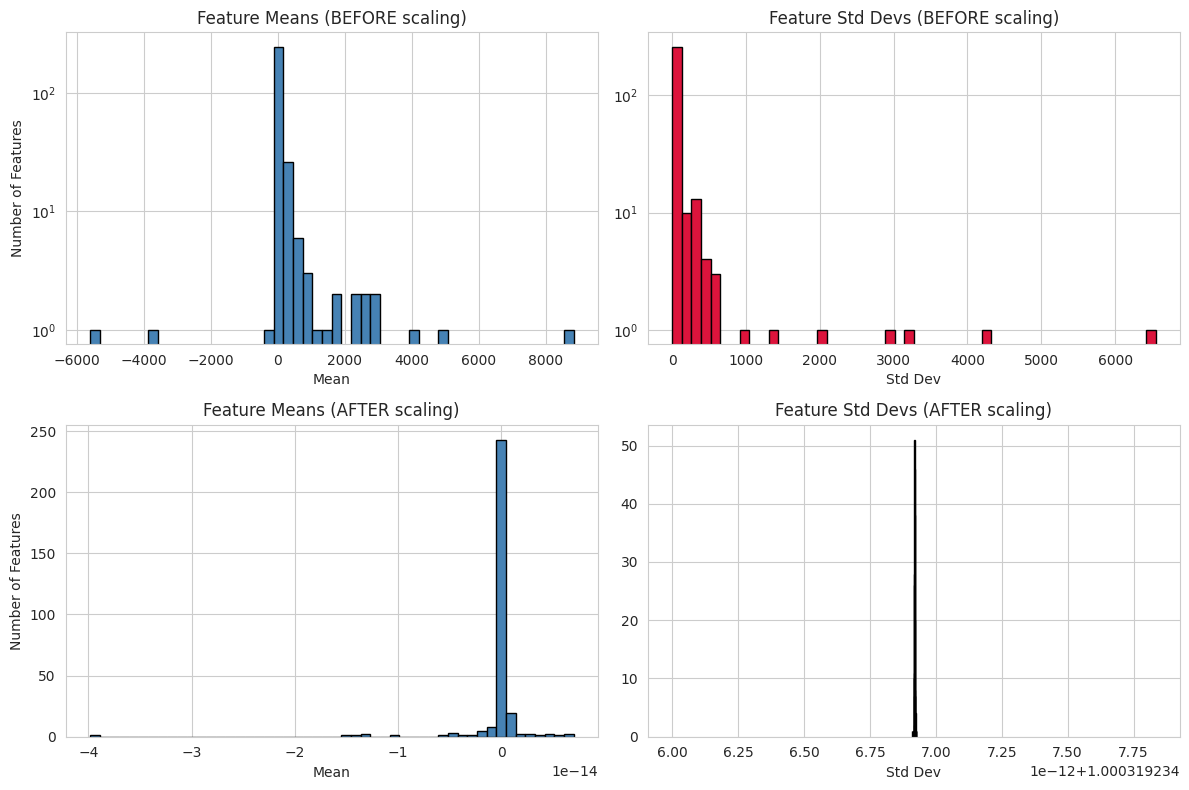


Figure saved as 'preprocessing_before_after.png'


In [9]:
# Compare distribution of feature means and stds before and after scaling
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Before scaling — feature means
axes[0, 0].hist(X_imputed.mean(), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Feature Means (BEFORE scaling)')
axes[0, 0].set_xlabel('Mean')
axes[0, 0].set_ylabel('Number of Features')
axes[0, 0].set_yscale('log')

# Before scaling — feature stds
axes[0, 1].hist(X_imputed.std(), bins=50, color='crimson', edgecolor='black')
axes[0, 1].set_title('Feature Std Devs (BEFORE scaling)')
axes[0, 1].set_xlabel('Std Dev')
axes[0, 1].set_yscale('log')

# After scaling — feature means
axes[1, 0].hist(X_scaled.mean(), bins=50, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Feature Means (AFTER scaling)')
axes[1, 0].set_xlabel('Mean')
axes[1, 0].set_ylabel('Number of Features')

# After scaling — feature stds
axes[1, 1].hist(X_scaled.std(), bins=50, color='crimson', edgecolor='black')
axes[1, 1].set_title('Feature Std Devs (AFTER scaling)')
axes[1, 1].set_xlabel('Std Dev')

plt.tight_layout()
plt.savefig('preprocessing_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'preprocessing_before_after.png'")

## Step 5: Save Preprocessed Dataset

Persist the cleaned, scaled feature matrix and labels to disk for use
by the modelling notebook. Save the fitted imputer and scaler too —
they'll be needed to apply the same transformations to new data
(e.g., the ESP32 simulation in Wokwi).

In [10]:
# Create output directory
import os
os.makedirs('preprocessed', exist_ok=True)

# Save preprocessed features and labels as numpy arrays (faster to load than CSV)
np.save('preprocessed/X_preprocessed.npy', X_scaled.values)
np.save('preprocessed/y.npy', y.values)

# Also save as CSV for inspection
X_scaled.to_csv('preprocessed/X_preprocessed.csv', index=False)

# Save the kept feature names (we'll need to know which original features survived)
feature_names = X_scaled.columns.tolist()
with open('preprocessed/kept_features.txt', 'w') as f:
    for name in feature_names:
        f.write(f"{name}\n")

# Save the fitted imputer and scaler
joblib.dump(imputer, 'preprocessed/imputer.joblib')
joblib.dump(scaler, 'preprocessed/scaler.joblib')

print("✅ Saved preprocessed dataset:")
print(f"   X_preprocessed.npy   shape: {X_scaled.shape}")
print(f"   y.npy                shape: {y.shape}")
print(f"   X_preprocessed.csv   (CSV version)")
print(f"   kept_features.txt    ({len(feature_names)} feature names)")
print(f"   imputer.joblib       (median imputer)")
print(f"   scaler.joblib        (z-score scaler)")

✅ Saved preprocessed dataset:
   X_preprocessed.npy   shape: (1567, 297)
   y.npy                shape: (1567,)
   X_preprocessed.csv   (CSV version)
   kept_features.txt    (297 feature names)
   imputer.joblib       (median imputer)
   scaler.joblib        (z-score scaler)


In [11]:
# Summary of preprocessing pipeline
print("="*60)
print("PREPROCESSING PIPELINE SUMMARY")
print("="*60)
print()
print(f"Input:  {X.shape[0]} samples × {X.shape[1]} features")
print(f"Output: {X_scaled.shape[0]} samples × {X_scaled.shape[1]} features")
print()
print("Transformations applied:")
print(f"  1. Dropped {X.shape[1] - X_step1.shape[1]} features (≥50% missing)")
print(f"  2. Dropped {X_step1.shape[1] - X_step2.shape[1]} features (zero/near-zero variance)")
print(f"  3. Imputed 7,052 missing values (median strategy)")
print(f"  4. Standardised all features (z-score)")
print()
print(f"Total features removed: {X.shape[1] - X_scaled.shape[1]} ({(X.shape[1] - X_scaled.shape[1])/X.shape[1]*100:.1f}%)")
print(f"Class distribution preserved: {dict(pd.Series(y).value_counts())}")
print()
print("✅ Pipeline complete — ready for modelling")

PREPROCESSING PIPELINE SUMMARY

Input:  1567 samples × 590 features
Output: 1567 samples × 297 features

Transformations applied:
  1. Dropped 28 features (≥50% missing)
  2. Dropped 265 features (zero/near-zero variance)
  3. Imputed 7,052 missing values (median strategy)
  4. Standardised all features (z-score)

Total features removed: 293 (49.7%)
Class distribution preserved: {-1: np.int64(1463), 1: np.int64(104)}

✅ Pipeline complete — ready for modelling


## Conclusion

The SECOM dataset has been reduced from 590 raw features to 297
informative features after dropping high-missing and constant-variance
columns. Median imputation and z-score standardisation were applied
to handle remaining missing values and scale heterogeneity respectively.

The preprocessed dataset is saved to `/preprocessed/` and is ready
for the modelling notebook (`03_baseline_models.ipynb`).

### Files Produced
- `X_preprocessed.npy` — feature matrix (1567 × 297)
- `y.npy` — labels (1567,)
- `imputer.joblib` — fitted median imputer (for transforming new data)
- `scaler.joblib` — fitted standardiser (for transforming new data)
- `kept_features.txt` — names of surviving features
- `preprocessing_before_after.png` — visualisation of scaling effect

### Key Decisions:
1. **Drop threshold of 50% missing:** Conservative — keeps features
   with up to 50% missingness, which can still be imputed reliably.
2. **Median imputation:** Robust to outliers (real sensor anomalies).
3. **Standardisation across full dataset:** For exploration only.
   The modelling notebook will refit on training split to prevent
   data leakage.